In [3]:
#imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler, WeightedRandomSampler
from torchvision import transforms, utils
from torch.autograd import Variable

import numpy as np
import pandas as pd
import math, copy, time

import matplotlib.pyplot as plt
import seaborn

from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from tqdm import trange
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import random
import re
from nltk.corpus import wordnet

#importing the model
from networks import *
#import helper util functions
from utils import do_syn_ant_augmentation, LogReader, LogTokenizer, get_data, get_padded_data, get_data_a
#importing the trainer, predictor and the loss
from trainer import run_train, run_test, SimpleLossCompute

torch.random.seed = 0
np.random.seed(0)

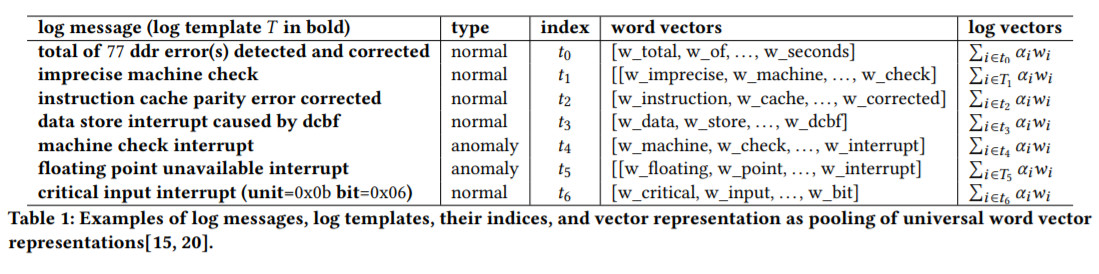

In [4]:
#helper function to create the model --> the model is in networks.py
def make_model(src_vocab, tgt_vocab, N=3, 
               d_model=512, d_ff=2048, h=8, dropout=0.1, max_len=20):
    "Helper: Construct a model from hyperparameters."
    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout, max_len)
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab))
    
    # This was important from their code. 
    # Initialize parameters with Glorot / fan_avg.
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model

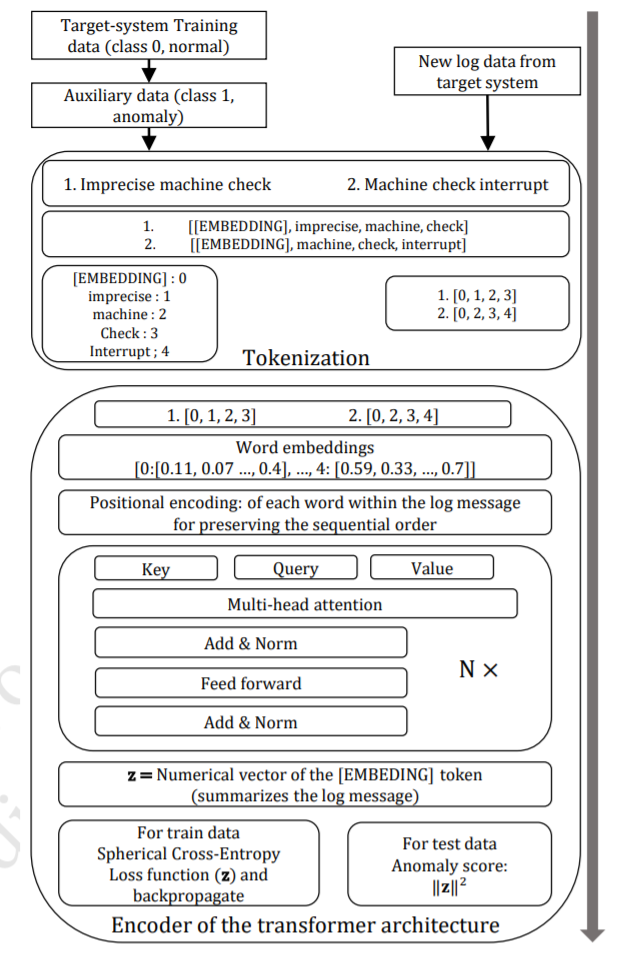

In [16]:
#read the auxiliary datasets
log_file = 'BGL.log'
input_dir  = '../data/'
output_dir = '../outputs/' 
log_format = '<t> <Timestamp> <Date> <Node> <Time> <NodeRepeat> <Type> <Component> <Level> <Content>'  #BGL
regex = []
every_n = 1
aux_normal, aux_anomalies = get_data(log_file, input_dir, output_dir, log_format, regex, 
                                     every_n=every_n, aux=300000, max_lines=False)

In [17]:
log_file = 'spirit2'
input_dir  = '../data/'  # The input directory of log file
output_dir = '../outputs/'  # The output directory of parsing results
log_format = '<t> <Timestamp> <Date> <User> <Month> <Day> <Time> <Location> <Content>'  #spirit2
regex = [] 
every_n = 100
aux_size = 100000
aux_normal1, aux_anomalies1 = get_data(log_file, input_dir, output_dir, log_format, regex, 
                                       every_n=every_n, aux=aux_size, max_lines=False)

In [18]:
log_file = 'Intrepid_RAS_0901_0908_scrubbed'
input_dir  = '../data/'
output_dir = '../outputs/' 
log_format = '<f> <a>          <c>       <d>                  <e>    <t> <Content>'  #BGL
regex = []
every_n = 1
aux_anomalies_t, tl = get_data_a(log_file, input_dir, output_dir, log_format, regex, 
                                 every_n=every_n, aux=False, max_lines=False)
aux_anomalies2 = aux_anomalies_t[tl==0]
aux_normal2 = aux_anomalies_t[tl==1]

In [19]:
#concat the auxiliary dataasets to one
aux_normal = np.array([])
aux_anomalies = np.append(aux_anomalies, aux_anomalies1)
aux_anomalies = np.append(aux_anomalies, aux_anomalies2)

In [20]:
#sampling function, helper for other experiments where we vary the size of the auxiliary dataset
import copy
aux_an = copy.deepcopy(aux_anomalies)
aux_anomalies = np.random.choice(aux_anomalies, size=250000, replace=False)
aux_anomalies.shape

(100000,)

In [127]:
#read the target dataset
log_file = 'tbird2'
input_dir  = '../data/'  # The input directory of log file
output_dir = '../outputs/'  # The output directory of parsing results
log_format = '<t> <Timestamp> <Date> <User> <Month> <Day> <Time> <Location> <Component>(\[<PID>\])?: <Content>'  #thunderbird
regex = [] 
every_n = 1
log_payload, true_labels = get_data(log_file, input_dir, output_dir, log_format, regex, every_n=every_n,
                                    aux=False, max_lines=5000000)

In [128]:
df_size = len(log_payload)
df_size

4999991

In [129]:
true_labels = true_labels.reshape(-1,1)

In [130]:
log_payload_original = copy.deepcopy(log_payload)
true_labels_original = copy.deepcopy(true_labels)

In [131]:
ratio = 0.8 #train_ratio, the test here is 0.2

In [132]:
#append the anomalies to the full data
log_payload = np.append(log_payload.values.reshape(-1,1), aux_anomalies.reshape(-1,1), axis=0)
true_labels = np.append(true_labels,  np.ones(len(aux_anomalies)).reshape(-1,1), axis=0).flatten()

In [133]:
log_payload.shape, true_labels.shape

((5099991, 1), (5099991,))

In [134]:
tokenizer = LogTokenizer()
df_len = int(log_payload.shape[0])
data_tokenized = []
for i in trange(0, df_len):
    tokenized = tokenizer.tokenize(log_payload[i][0])
    data_tokenized.append(tokenized)

100%|██████████| 5099991/5099991 [01:02<00:00, 82050.22it/s] 


In [135]:
data_token_indexed = np.asanyarray(data_tokenized)

In [149]:
ratio = 0.1
train_size = round(df_size * ratio)
df_size, train_size

(4999991, 499999)

In [150]:
data_token_indexed_test = data_token_indexed[train_size:df_size]
data_token_indexed_train = np.append(data_token_indexed[:train_size][true_labels[:train_size]==0], 
                                     data_token_indexed[df_size:],axis=0)

test_ground_labels = true_labels[train_size:df_size]
train_ground_labels = np.append(true_labels[:train_size][true_labels[:train_size]==0].flatten(), 
                                true_labels[df_size:].flatten(),axis=0)

In [151]:
a = np.intersect1d(np.unique(data_token_indexed_test), np.unique(data_token_indexed_train), assume_unique=True)
#unique in test - intersection  
print("There are:",np.unique(data_token_indexed_test).shape[0] - a.shape[0],"unique log messages")

There are: 1091 unique log messages


In [36]:
data_token_indexed_test.shape, data_token_indexed_train.shape, train_ground_labels.shape, test_ground_labels.shape

((942699,), (3568617,), (3568617,), (942699,))

In [37]:
batch_size = 2048
transform_to_tensor = transforms.Lambda(lambda lst: torch.tensor(lst))
train_data = TensorDataset(torch.tensor(get_padded_data(data_token_indexed_train, pad_len=50), dtype=torch.long), torch.tensor(train_ground_labels.astype(np.int32), dtype=torch.long))
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

test_data = TensorDataset(torch.tensor(get_padded_data(data_token_indexed_test, pad_len=50), dtype=torch.long), torch.tensor(test_ground_labels.astype(np.int32).flatten(), dtype=torch.long))
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)


In [38]:
class SimpleLossCompute:
    "A simple loss compute and train function."
    def __init__(self, model, criterion, opt=None, is_test=False):
        self.model = model
        self.criterion = criterion
        self.opt = opt
        self.is_test = is_test
        
    def __call__(self, x, y, dist)
        loss = torch.mean((1-y)*torch.sqrt(dist) - (y)*torch.log(1-torch.exp(-torch.sqrt(dist))))
        if not self.is_test:
            loss.backward()
            if self.opt is not None:
                self.opt.step()
                self.opt.zero_grad()

        return loss.item()

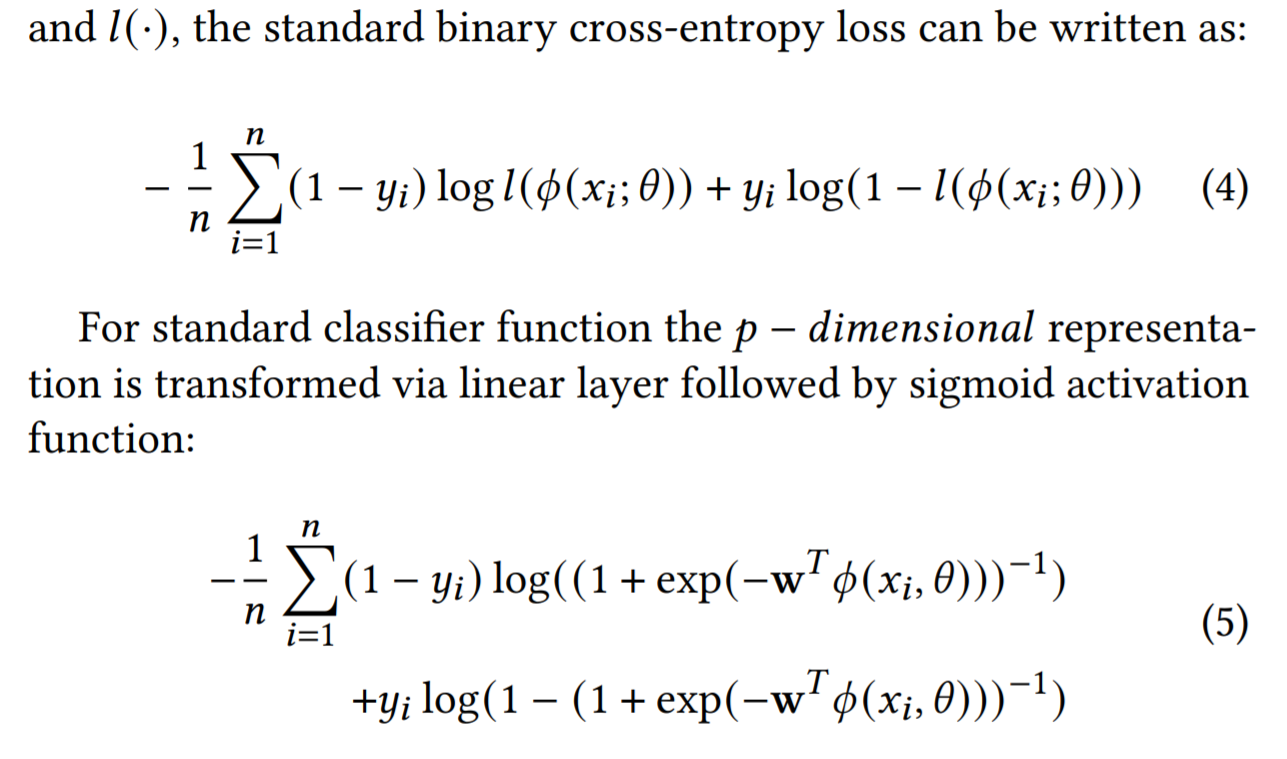

In [41]:
torch.cuda.set_device(1)
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
criterion = nn.CrossEntropyLoss(weight=torch.tensor([0.3,1.0]).cuda())#
model = make_model(tokenizer.n_words, 2, N=2, h=2, d_model=16, d_ff=16, dropout=0.05, max_len=50)
model.cuda()
model_opt = torch.optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.999), weight_decay=0.001)
max_auc = 0.0
max_distances = 0
for epoch in range(30):
    #training
    model.train()
    print("Epoch",epoch)
    run_train(train_dataloader, model, 
             SimpleLossCompute(model, criterion, model_opt), step_size=100)
    torch.save(model.state_dict(), '../output/models/model_'+str(epoch)+'.pt')
    
    
    #test
    model.eval()
    preds, distances = run_test(test_dataloader, model, 
                        SimpleLossCompute(model, criterion, None, is_test=True), step_size=100)

    preds = np.array(preds)
    auc = roc_auc_score(test_ground_labels.astype(np.int32), distances)
    print("AUC:", auc)
    if auc > max_auc:
        max_auc = auc
        fpr, tpr, thresholds = roc_curve(test_ground_labels.astype(np.int32), distances, pos_label=1)
        np.save(str(aux_size)+'_without8020.npy',[fpr, tpr, thresholds])
        print(roc_auc_score(test_ground_labels.astype(np.int32), distances))
        max_distances = distances
    

Epoch 0
Epoch Step: 1 / 1743 Loss: 3.750049
Epoch Step: 101 / 1743 Loss: 3.689914
Epoch Step: 201 / 1743 Loss: 3.624897
Epoch Step: 301 / 1743 Loss: 3.476648
Epoch Step: 401 / 1743 Loss: 3.378373
Epoch Step: 501 / 1743 Loss: 3.307432
Epoch Step: 601 / 1743 Loss: 3.237291
Epoch Step: 701 / 1743 Loss: 3.130223
Epoch Step: 801 / 1743 Loss: 3.074240
Epoch Step: 901 / 1743 Loss: 2.997763
Epoch Step: 1001 / 1743 Loss: 2.938444
Epoch Step: 1101 / 1743 Loss: 2.849445
Epoch Step: 1201 / 1743 Loss: 2.795755
Epoch Step: 1301 / 1743 Loss: 2.723918
Epoch Step: 1401 / 1743 Loss: 2.667207
Epoch Step: 1501 / 1743 Loss: 2.611977
Epoch Step: 1601 / 1743 Loss: 2.535326
Epoch Step: 1701 / 1743 Loss: 2.470407
Epoch Step: 1 / 461 Loss: 2.509859
Epoch Step: 101 / 461 Loss: 2.509858
Epoch Step: 201 / 461 Loss: 1.690483
Epoch Step: 301 / 461 Loss: 2.510088
Epoch Step: 401 / 461 Loss: 2.505223
AUC: 0.5547883034351377
0.5547883034351377
Epoch 1
Epoch Step: 1 / 1743 Loss: 2.448608
Epoch Step: 101 / 1743 Loss: 2.3

AUC: 0.9710869707058845
Epoch 9
Epoch Step: 1 / 1743 Loss: 0.006448
Epoch Step: 101 / 1743 Loss: 0.005775
Epoch Step: 201 / 1743 Loss: 0.006077
Epoch Step: 301 / 1743 Loss: 0.006350
Epoch Step: 401 / 1743 Loss: 0.005066
Epoch Step: 501 / 1743 Loss: 0.006368
Epoch Step: 601 / 1743 Loss: 0.007743
Epoch Step: 701 / 1743 Loss: 0.007927
Epoch Step: 801 / 1743 Loss: 0.008424
Epoch Step: 901 / 1743 Loss: 0.005320
Epoch Step: 1001 / 1743 Loss: 0.005442
Epoch Step: 1101 / 1743 Loss: 0.005883
Epoch Step: 1201 / 1743 Loss: 0.013752
Epoch Step: 1301 / 1743 Loss: 0.006046
Epoch Step: 1401 / 1743 Loss: 0.014617
Epoch Step: 1501 / 1743 Loss: 0.005395
Epoch Step: 1601 / 1743 Loss: 0.003987
Epoch Step: 1701 / 1743 Loss: 0.006681
Epoch Step: 1 / 461 Loss: 0.003681
Epoch Step: 101 / 461 Loss: 0.003692
Epoch Step: 201 / 461 Loss: 0.057940
Epoch Step: 301 / 461 Loss: 0.016786
Epoch Step: 401 / 461 Loss: 0.011674
AUC: 0.9719657237887995
Epoch 10
Epoch Step: 1 / 1743 Loss: 0.007476
Epoch Step: 101 / 1743 Los

KeyboardInterrupt: 

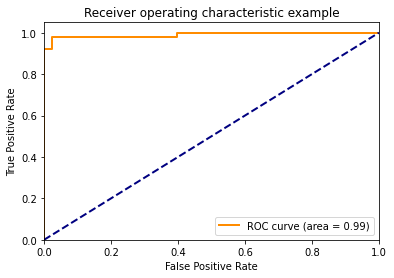

In [42]:
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_score(test_ground_labels.astype(np.int32), max_distances))
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

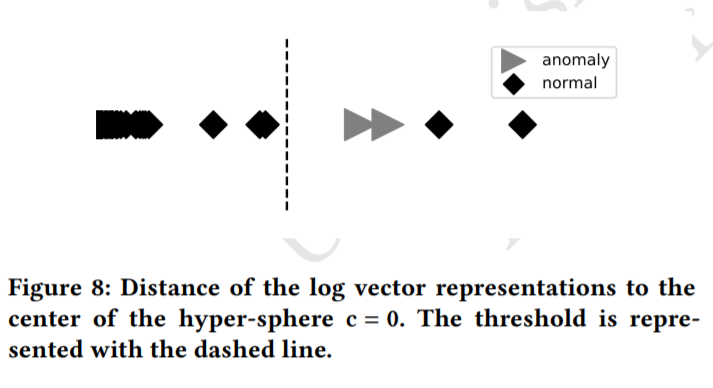

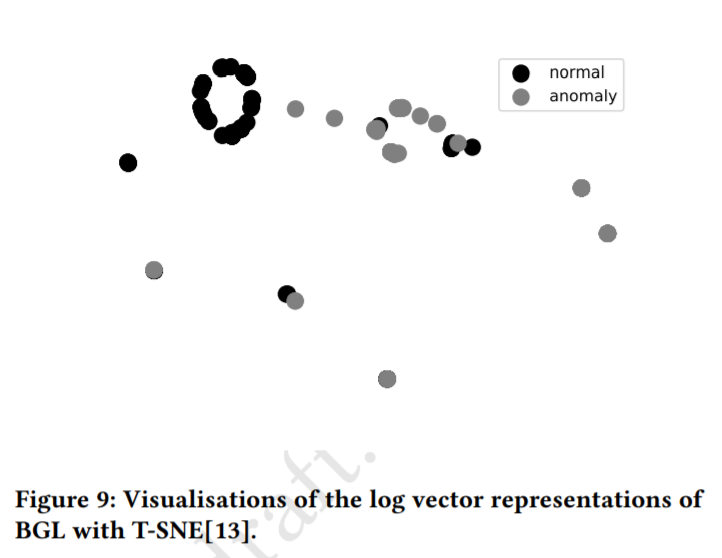

In [56]:
thresholds[tpr>0.9]

array([1.01277065e+01, 1.01067591e+01, 1.00858126e+01, 9.95450592e+00,
       9.79491329e+00, 9.18864822e+00, 9.11237907e+00, 8.98869324e+00,
       8.89010906e+00, 8.86045837e+00, 2.78523088e+00, 3.98056567e-01,
       3.88363957e-01, 3.18818748e-01, 3.18808198e-01, 2.47958243e-01,
       2.37755075e-01, 1.83603704e-01, 4.94003706e-02, 1.98673140e-02,
       1.87607687e-02, 1.83945298e-02, 1.67029202e-02, 1.50662716e-02,
       8.81393347e-03, 8.61223973e-03, 8.04235414e-03, 7.90559687e-03,
       6.58272905e-03, 6.11833716e-03, 6.11598231e-03, 5.95396431e-03,
       5.45342686e-03, 5.34958392e-03, 5.14972024e-03, 4.39342950e-03,
       4.32310533e-03, 3.37432721e-03, 3.32905864e-03, 2.57066870e-03,
       2.23524286e-03, 2.00337358e-03, 1.86637195e-03, 1.78428320e-03,
       1.73370249e-03, 1.70556677e-03, 1.67384068e-03, 1.50606164e-03,
       1.39669830e-03, 1.39254215e-03, 1.34280254e-03, 1.28223526e-03,
       1.27199513e-03, 1.23302103e-03, 1.20914285e-03, 1.20906276e-03,
      

In [57]:
tr = [1.01277065e+01]
for t in tr:
    res=[]
    for d in max_distances:
        if d > t:
            res.append(1)
        else:
            res.append(0)


    print(f1_score(test_ground_labels.astype(np.int32), res))
    print(recall_score(test_ground_labels.astype(np.int32), res))
    print(precision_score(test_ground_labels.astype(np.int32), res))
    print(accuracy_score(test_ground_labels.astype(np.int32), res))
    print(confusion_matrix(test_ground_labels.astype(np.int32), res))


0.9581532504952277
0.9196681286865588
1.0
0.996056005151167
[[896416      0]
 [  3718  42565]]
0.9581532504952277
0.9196681286865588
1.0
0.996056005151167
[[896416      0]
 [  3718  42565]]
0.9573020567431713
0.9196681286865588
0.998147453334584
0.9959722032165091
[[896337     79]
 [  3718  42565]]


In [53]:
a = np.intersect1d(np.unique(data_token_indexed_test), np.unique(data_token_indexed_train), assume_unique=True)
#unique in test - intersection  
print("There are:",np.unique(data_token_indexed_test).shape[0] - a.shape[0],"unique log messages")

In [70]:
#unique in test - intersection  
print("There are:",np.unique(data_token_indexed_test).shape[0] - a.shape[0],"unique log messages")

There are: 465 unique log messages


# **RESULTS**

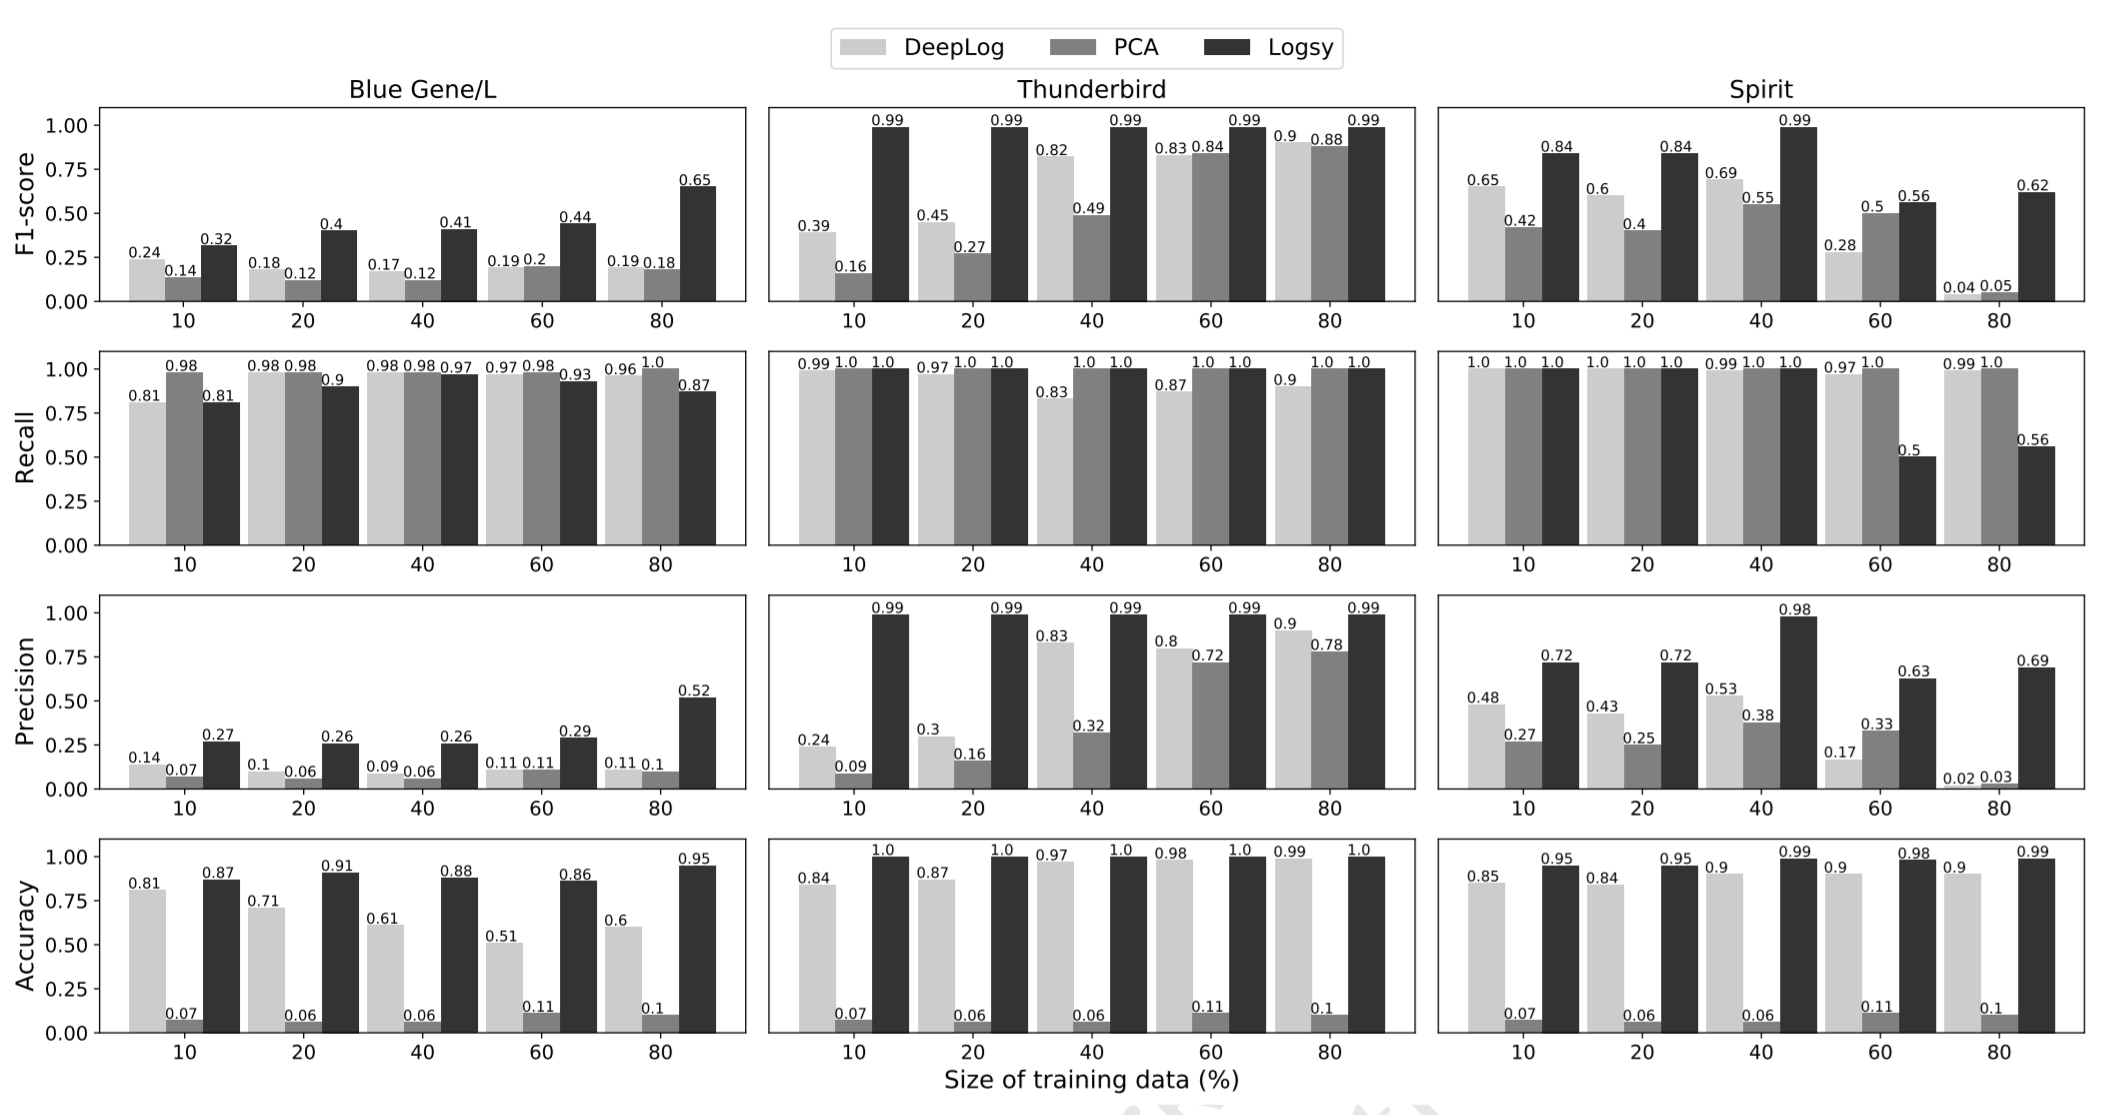

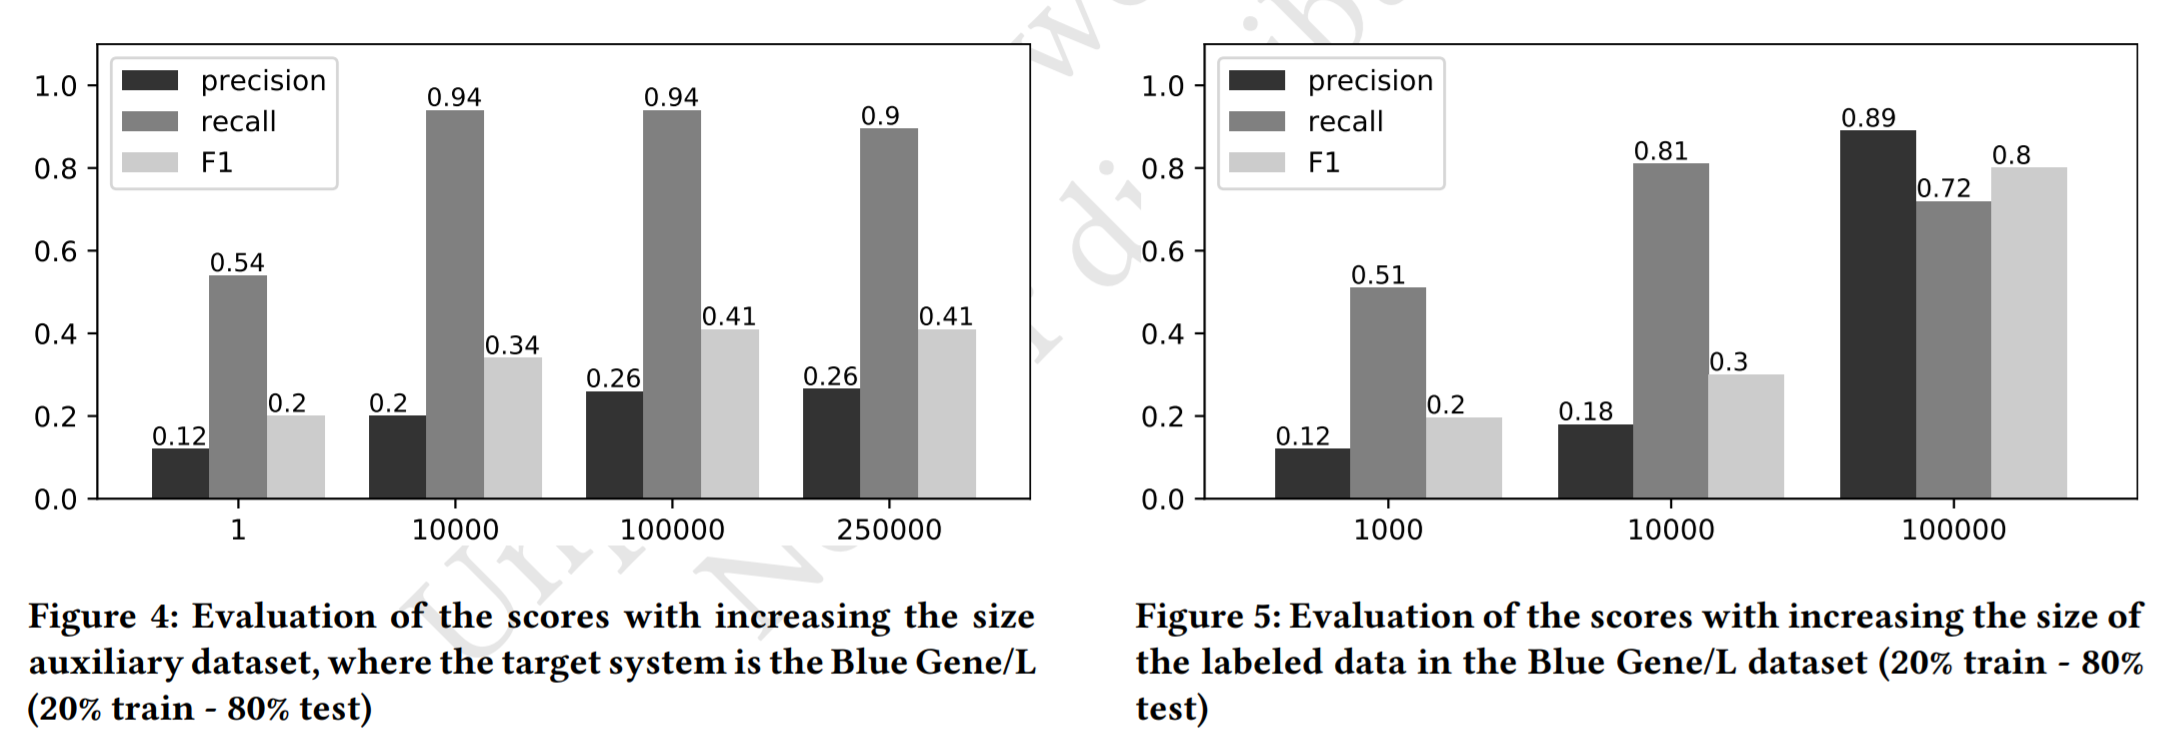

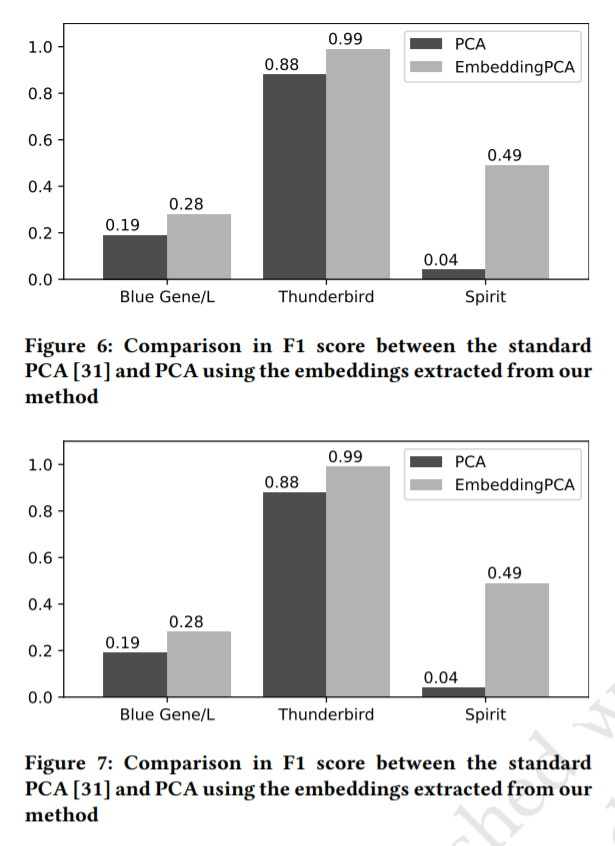